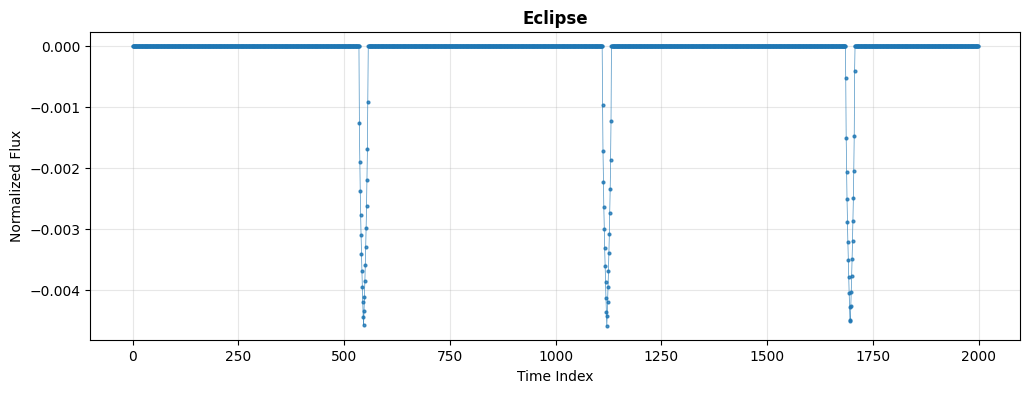

In [1]:
import numpy as np

import torch
from torch.utils.data import DataLoader, Dataset

from LightCurve import test_train_lc
from functions.functions import confusion_matrix

import matplotlib.pyplot as plt

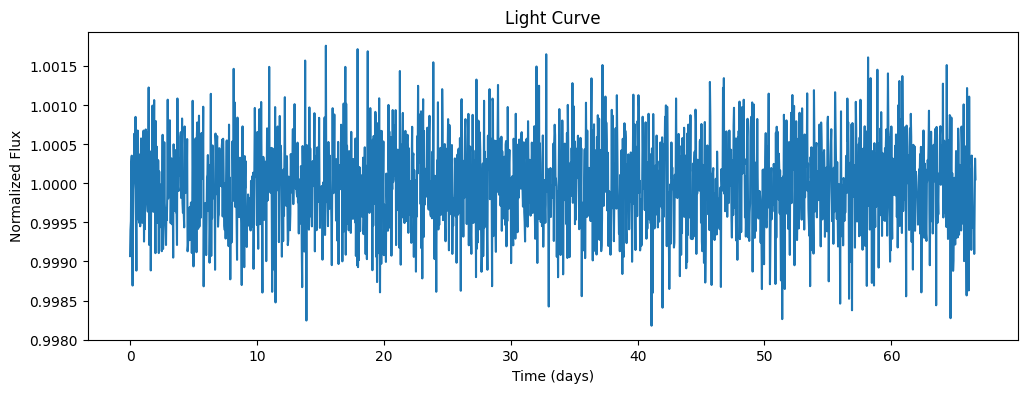

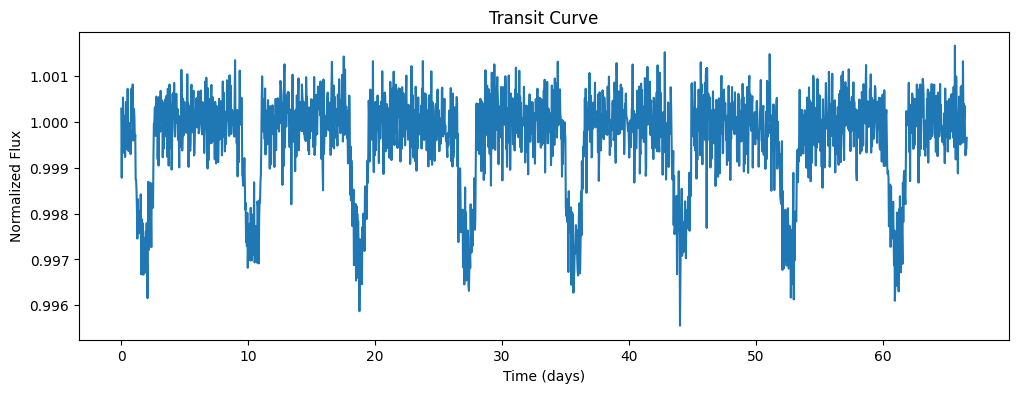

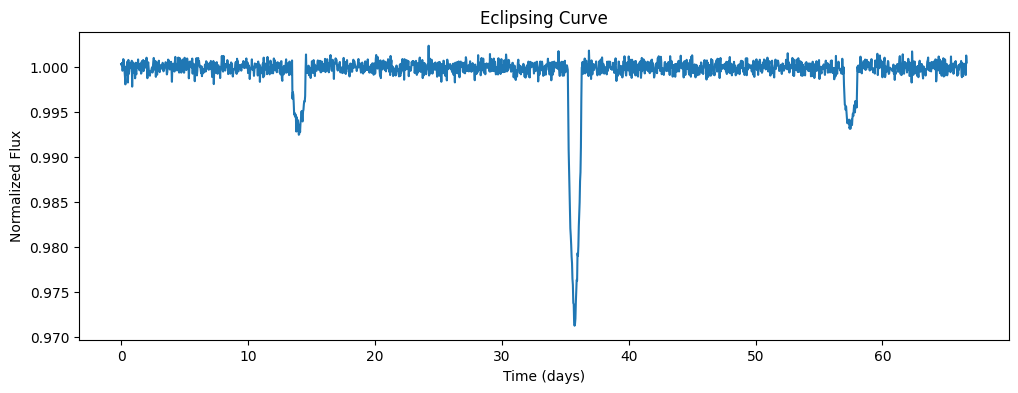

In [2]:
num_lc = 50000
lc_types=[0, 1, 2]
per_types=[0.75, 0.15, 0.10]

X_train, X_test, y_train, y_test = test_train_lc(num_lc=num_lc, lc_types=lc_types, per_types=per_types, check=1)

X_train = (X_train - np.median(X_train, axis=1, keepdims=True)) / (np.std(X_train, axis=1, keepdims=True) + 1e-8)
X_test  = (X_test  - np.median(X_test,  axis=1, keepdims=True)) / (np.std(X_test,  axis=1, keepdims=True) + 1e-8)


X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

In [3]:
class LightCurveDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = LightCurveDataset(X_train, y_train)
test_ds  = LightCurveDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN1D(nn.Module):
    def __init__(self, n_points):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5)
        self.pool = nn.MaxPool1d(2)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_points)
            z = self.pool(F.relu(self.conv1(dummy)))
            z = self.pool(F.relu(self.conv2(z)))
            n_features = z.shape[1] * z.shape[2]

        self.fc1 = nn.Linear(n_features, 64)
        self.fc2 = nn.Linear(64, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)



In [5]:
import torch.nn as nn

model = CNN1D(n_points=2000)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [6]:
num_epochs = 20

loss_saved = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)              # (batch, 3)
        loss = criterion(outputs, y_batch)    # y_batch is (batch,)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    loss_saved.append(running_loss)
    print(f"Epoch {epoch+1}, loss={running_loss/len(train_loader):.4f}")

Epoch 1, loss=0.1228
Epoch 2, loss=0.0882
Epoch 3, loss=0.0767
Epoch 4, loss=0.0717
Epoch 5, loss=0.0664
Epoch 6, loss=0.0544
Epoch 7, loss=0.0432
Epoch 8, loss=0.0281
Epoch 9, loss=0.0178
Epoch 10, loss=0.0135
Epoch 11, loss=0.0081
Epoch 12, loss=0.0053
Epoch 13, loss=0.0070
Epoch 14, loss=0.0021
Epoch 15, loss=0.0070
Epoch 16, loss=0.0020
Epoch 17, loss=0.0065
Epoch 18, loss=0.0020
Epoch 19, loss=0.0004
Epoch 20, loss=0.0001


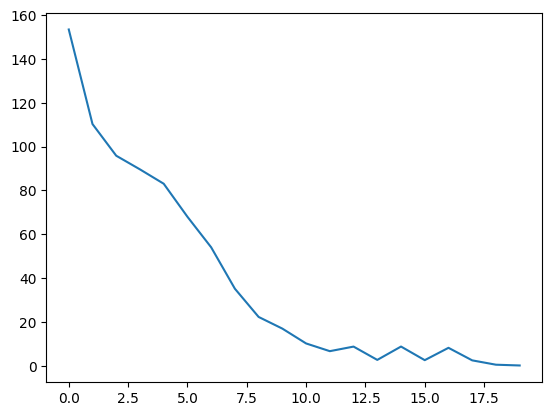

In [7]:
plt.figure()
plt.plot(np.arange(0, num_epochs), loss_saved)

In [8]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)  # (batch, 3)
        preds = outputs.argmax(dim=1)  # (batch,)

        all_preds.append(preds.cpu())
        all_true.append(y_batch.cpu())

all_preds = torch.cat(all_preds)
all_true = torch.cat(all_true)

normal     | Precision: 0.999 | Recall: 1.000
transit    | Precision: 0.883 | Recall: 0.911
eclipsing  | Precision: 0.868 | Recall: 0.819
Macro Precision: 0.9163413051801682
Macro Recall:    0.9100666666614671


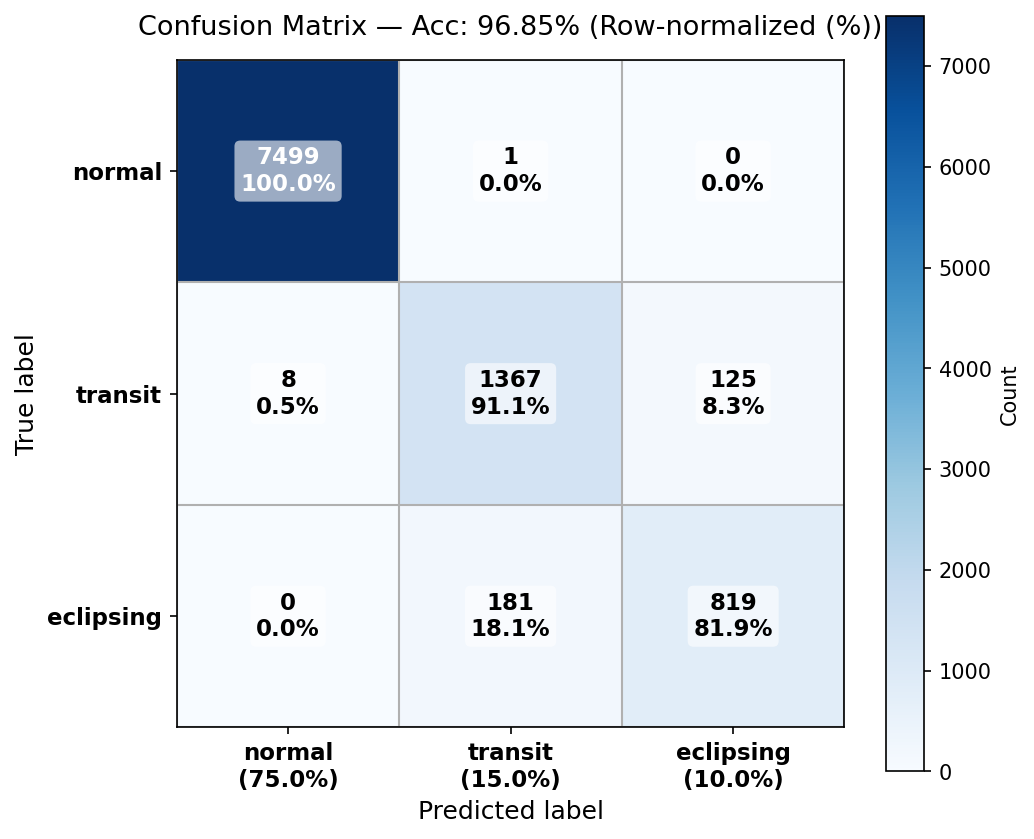

array([[7499,    1,    0],
       [   8, 1367,  125],
       [   0,  181,  819]])

In [9]:
save_info = [num_lc, lc_types, per_types, num_epochs]
confusion_matrix(all_preds, all_true, save_info)